In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import exchange_calendars as xcals

In [2]:
aapl= yf.Ticker("aapl")
aapl

aapl_historical = aapl.history(start="2026-06-01", end="2026-06-17", interval="5m")
aapl_historical

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-01 09:30:00-04:00,309.535004,310.679993,308.500000,310.029999,3861073,0.0,0.0
2026-06-01 09:35:00-04:00,310.010010,310.929993,309.589996,309.879913,717238,0.0,0.0
2026-06-01 09:40:00-04:00,309.850006,310.100006,309.160004,309.525513,633466,0.0,0.0
2026-06-01 09:45:00-04:00,309.549988,310.299988,309.279999,310.119995,575764,0.0,0.0
2026-06-01 09:50:00-04:00,310.149994,310.619995,309.339996,309.399994,631506,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-16 15:35:00-04:00,298.399994,298.599915,298.350006,298.565002,262941,0.0,0.0
2026-06-16 15:40:00-04:00,298.559998,298.714996,298.489990,298.570007,264710,0.0,0.0
2026-06-16 15:45:00-04:00,298.570007,299.010010,298.549988,299.010010,717068,0.0,0.0


In [3]:
# 1. Flatten the MultiIndex columns
aapl_historical.columns = aapl_historical.columns.flatten() if hasattr(aapl_historical.columns, 'flatten') else aapl_historical.columns

# 2. Reset the index
df_cleaned = aapl_historical.reset_index()

# 3. Format the Date (It will now find 'Date' successfully)
df_cleaned['Date'] = df_cleaned['Datetime'].dt.strftime('%Y-%m-%d')


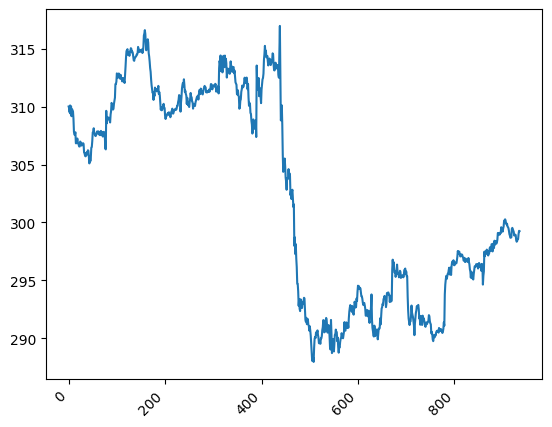

In [7]:
plt.plot(df_cleaned.index, df_cleaned['Close'])
plt.xticks(rotation = 45, ha = 'right')
plt.show();

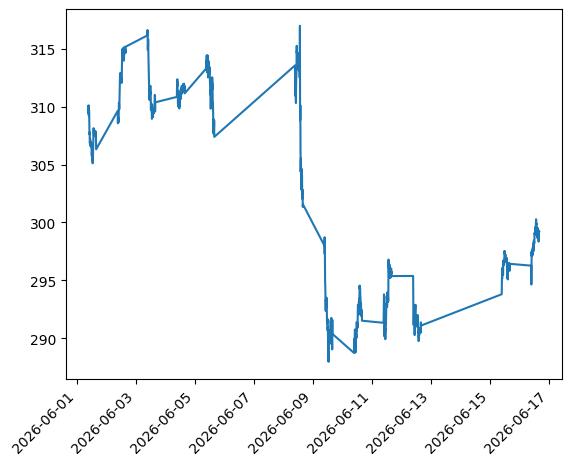

In [8]:
plt.plot(df_cleaned['Datetime'], df_cleaned['Close'])
plt.xticks(rotation = 45, ha = 'right')
plt.show();

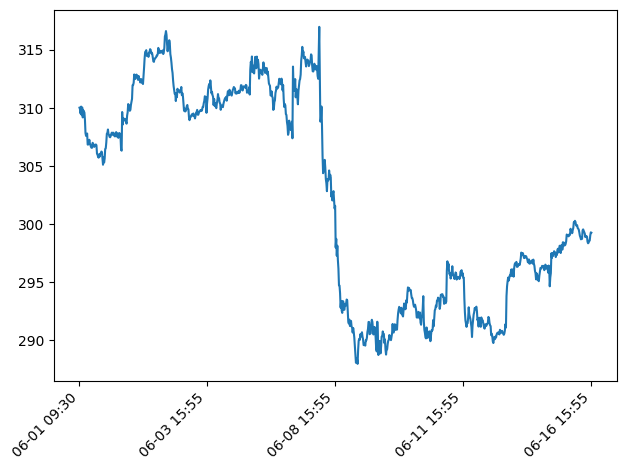

In [12]:
# 1. Plot using the index so the spacing remains perfectly uniform
plt.plot(df_cleaned.index, df_cleaned['Close'])

# 2. Pick a handful of evenly spaced positions for your ticks (e.g., 5 total ticks)
tick_positions = np.linspace(0, len(df_cleaned) - 1, num=5, dtype=int)

# 3. Grab the actual Datetime strings for those specific positions
# (Using .dt.strftime to keep the labels clean and readable)
tick_labels = df_cleaned['Datetime'].dt.strftime('%m-%d %H:%M').iloc[tick_positions]

# 4. Apply the custom ticks and labels
plt.xticks(ticks = tick_positions, labels=tick_labels, rotation=45, ha='right')

plt.tight_layout() # Prevents labels from getting cut off
plt.show()

In [13]:
df_cleaned['returns'] = df_cleaned['Close'].pct_change()

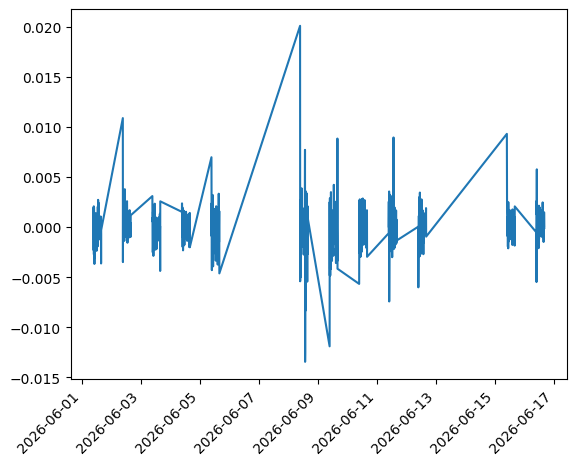

In [14]:
plt.plot(df_cleaned['Datetime'], df_cleaned['returns'])
plt.xticks(rotation = 45, ha = 'right')
plt.show()

In [17]:
#Average returns
average_return = df_cleaned['returns'].mean()

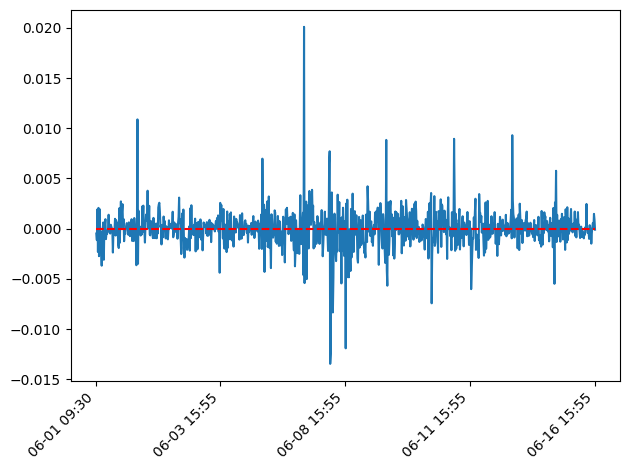

In [18]:
# 1. Plot using the index so the spacing remains perfectly uniform
plt.plot(df_cleaned.index, df_cleaned['returns'])

# 2. Pick a handful of evenly spaced positions for your ticks (e.g., 5 total ticks)
tick_positions = np.linspace(0, len(df_cleaned) - 1, num=5, dtype=int)

# 3. Grab the actual Datetime strings for those specific positions
# (Using .dt.strftime to keep the labels clean and readable)
tick_labels = df_cleaned['Datetime'].dt.strftime('%m-%d %H:%M').iloc[tick_positions]

# 4. Apply the custom ticks and labels
plt.xticks(ticks = tick_positions, labels=tick_labels, rotation=45, ha='right')

plt.plot(df_cleaned.index, [average_return]*len(df_cleaned), color='red', linestyle='--', label='Average Return')
plt.tight_layout() # Prevents labels from getting cut off
plt.show()